# Industrial Pump Data Analytics — Student Notebook

**Goal:** Clean, analyze and visualize pump data, then communicate at least 5 observations and 3 actionable insights.

**Important:** For every important output, explain what it means.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [17]:
df=pd.read_csv('../data/data.csv')
df.head()

,timestamp,pump_id,temperature_C,pressure_bar,flow_m3h,power_kW,rpm,vibration_mms,operating_hours,status
0,2026-01-01 00:00:00,P-103,63.16,4.528,184.96,24.38,1463.9,1.959,2500.00,Normal
1,2026-01-01 00:15:00,P-104,63.37,4.714,178.74,21.96,1416.8,1.682,2500.02,Normal
2,2026-01-01 00:30:00,P-104,59.61,4.763,187.17,26.58,1445.7,2.122,2500.03,Normal
3,2026-01-01 00:45:00,P-103,62.24,4.718,192.16,26.70,1430.4,1.678,2500.04,Normal
4,2026-01-01 01:00:00,P-102,61.94,4.504,171.03,19.63,1501.5,1.387,2500.06,Normal


## Exercise 1 — First look
How many rows/columns? Which columns are numerical/categorical? Is timestamp correctly typed?

In [4]:
print('Shape:',df.shape)
print('Columns:',df.columns.tolist())
df.info()
df.describe(include='all').T

Shape: (10003, 10)
Columns: ['timestamp', 'pump_id', 'temperature_C', 'pressure_bar', 'flow_m3h', 'power_kW', 'rpm', 'vibration_mms', 'operating_hours', 'status']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        10003 non-null  object 
 1   pump_id          10003 non-null  object 
 2   temperature_C    9883 non-null   float64
 3   pressure_bar     9923 non-null   float64
 4   flow_m3h         10003 non-null  float64
 5   power_kW         10003 non-null  float64
 6   rpm              10003 non-null  float64
 7   vibration_mms    9943 non-null   float64
 8   operating_hours  10003 non-null  float64
 9   status           10003 non-null  object 
dtypes: float64(7), object(3)
memory usage: 781.6+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,10003,10000,2026-01-02 06:00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pump_id,10003,4,P-101,2525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_C,9883.0,NaN,NaN,NaN,63.952527,3.42078,52.08,61.62,63.83,66.075,84.81
pressure_bar,9923.0,NaN,NaN,NaN,4.957934,0.257931,3.663,4.775,4.963,5.1505,5.743
flow_m3h,10003.0,NaN,NaN,NaN,212.099552,19.996753,149.1,195.83,211.7,228.34,273.59
power_kW,10003.0,NaN,NaN,NaN,29.811107,4.076545,18.27,26.525,29.69,32.93,51.66
rpm,10003.0,NaN,NaN,NaN,1449.919814,17.999715,1379.7,1438.0,1449.9,1461.8,1525.3
vibration_mms,9943.0,NaN,NaN,NaN,2.044399,0.483512,1.134,1.825,1.989,2.1525,8.81
operating_hours,10003.0,NaN,NaN,NaN,2574.970554,43.31548,2500.0,2537.465,2574.97,2612.475,2649.98
status,10003,2,Normal,9783,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Exercise 2 — Data quality
Find missing values and duplicates. Decide how you would handle them and explain why.

In [5]:
df.isnull().sum()
# TODO: duplicates

timestamp            0
pump_id              0
temperature_C      120
pressure_bar        80
flow_m3h             0
power_kW             0
rpm                  0
vibration_mms       60
operating_hours      0
status               0
dtype: int64

## Exercise 3 — Cleaning
Convert timestamp to datetime, remove duplicates and handle missing numerical values. Confirm the result.

In [6]:
df['timestamp']=pd.to_datetime(df['timestamp'])
# TODO: df.drop_duplicates()
# TODO: handle missing values
df.isnull().sum()

timestamp            0
pump_id              0
temperature_C      120
pressure_bar        80
flow_m3h             0
power_kW             0
rpm                  0
vibration_mms       60
operating_hours      0
status               0
dtype: int64

In [ ]:
df.missing_

## Exercise 4 — Basic statistics
Calculate mean, median, min, max and standard deviation for temperature, pressure, power and vibration. Which appears most variable?

In [7]:
cols=['temperature_C','pressure_bar','power_kW','vibration_mms']
df[cols].agg(['mean','median','min','max','std']).T

,mean,median,min,max,std
temperature_C,63.952527,63.830,52.080,84.810,3.420780
pressure_bar,4.957934,4.963,3.663,5.743,0.257931
power_kW,29.811107,29.690,18.270,51.660,4.076545
vibration_mms,2.044399,1.989,1.134,8.810,0.483512


## Exercise 5 — Grouping
Compare average power, temperature and vibration by pump ID.

In [8]:
df.groupby('pump_id')[['power_kW','temperature_C','vibration_mms']].mean().round(2)

,power_kW,temperature_C,vibration_mms
pump_id,,,
P-101,29.82,64.00,2.04
P-102,29.77,63.91,2.05
P-103,29.92,63.99,2.05
P-104,29.73,63.92,2.04


## Exercise 6 — Visualization
Create at least four meaningful plots: line, bar, histogram and scatter. Add labels/titles.

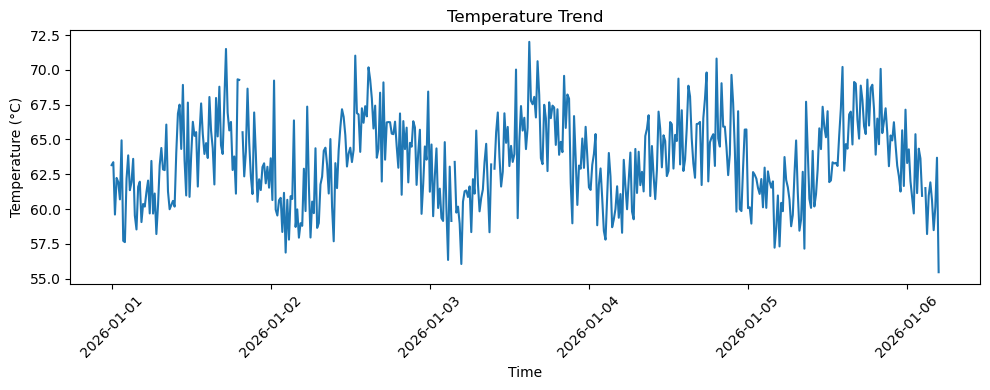

In [9]:
plt.figure(figsize=(10,4))
plt.plot(df['timestamp'].iloc[:500],df['temperature_C'].iloc[:500])
plt.xlabel('Time');plt.ylabel('Temperature (°C)');plt.title('Temperature Trend');plt.xticks(rotation=45);plt.tight_layout();plt.show()

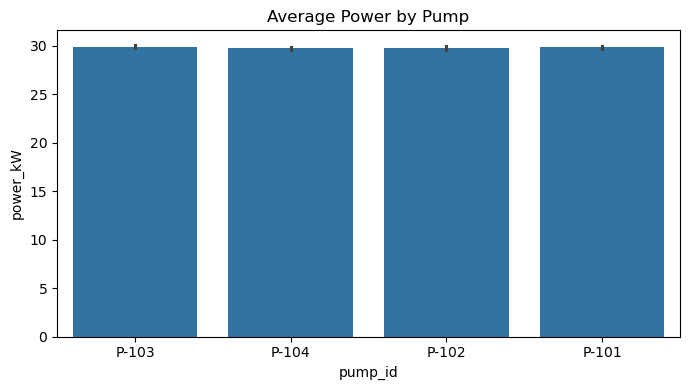

In [10]:
plt.figure(figsize=(7,4))
sns.barplot(data=df,x='pump_id',y='power_kW',estimator='mean')
plt.title('Average Power by Pump');plt.tight_layout();plt.show()

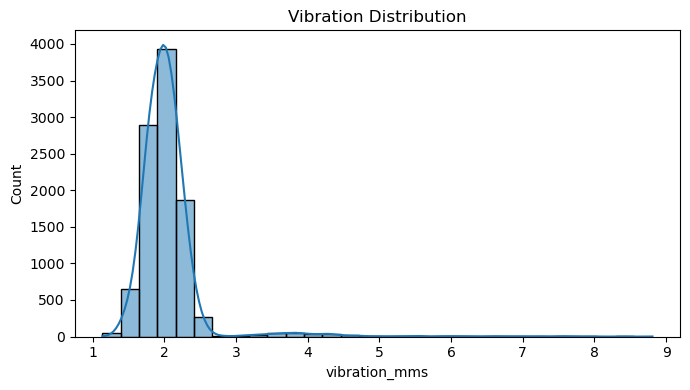

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(data=df,x='vibration_mms',bins=30,kde=True)
plt.title('Vibration Distribution');plt.tight_layout();plt.show()

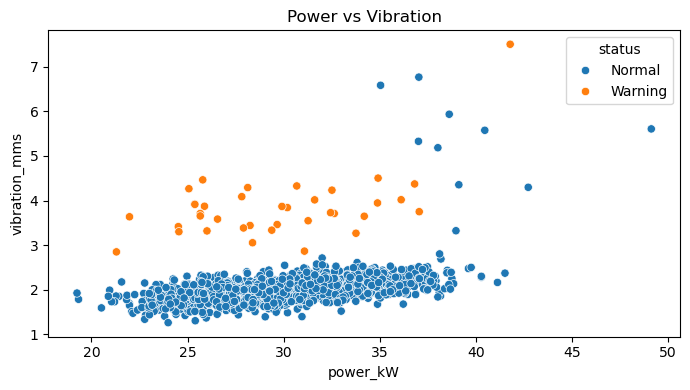

In [12]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=df.sample(1500,random_state=42),x='power_kW',y='vibration_mms',hue='status')
plt.title('Power vs Vibration');plt.tight_layout();plt.show()

## Exercise 7 — 24-hour pattern
Create an hour column and compare average temperature, power and vibration across hours 0–23.

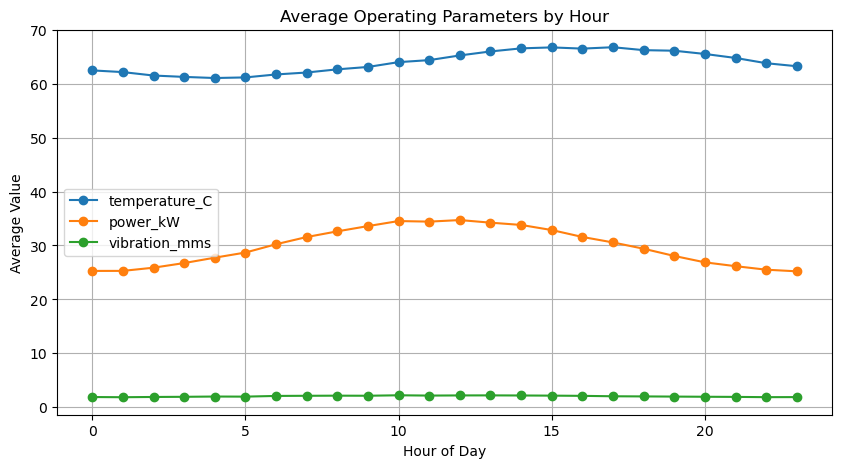

In [13]:
df['hour']=df['timestamp'].dt.hour
hourly=df.groupby('hour')[['temperature_C','power_kW','vibration_mms']].mean()
hourly.plot(figsize=(10,5),marker='o')
plt.title('Average Operating Parameters by Hour');plt.xlabel('Hour of Day');plt.ylabel('Average Value');plt.grid(True);plt.show()

## Exercise 8 — Interpretation
Write: (1) five observations, (2) three engineering/business insights, (3) two questions for further investigation, (4) one hypothesis for warning periods.